In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [88]:
import pandas as pd
import requests

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [89]:
df.head(3)

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260


In [90]:
df.describe()

,year,fertility_rate_hist
count,19402.000000,19402.000000
mean,1985.861612,3.936123
std,22.049134,1.991179
min,1891.000000,0.662000
25%,1967.000000,2.138210
50%,1986.000000,3.466000
75%,2005.000000,5.849000
max,2023.000000,8.864000


In [91]:
df.shape

(19402, 4)

In [92]:
mexico = df[(df['entity'] == 'Mexico')]

In [93]:
type(mexico)

pandas.DataFrame

In [94]:
mexico.head(3)

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731


In [95]:
japon = df[(df['entity'] == 'Japan')]

In [96]:
japon.head(3)

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373


In [97]:
type(df["entity"])

pandas.Series

In [98]:
anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()

In [99]:
type(anios_mexico), type(tasa_mexico), type(anios_japon), type(tasa_japon)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

In [100]:
promedio_mexico = np.mean(tasa_mexico)
maximo_mexico = np.max(tasa_mexico)

minimo_mexico = np.min(tasa_mexico)
desviacion_mexico = np.std(tasa_mexico)

promedio_japon = np.mean(tasa_japon)
maximo_japon = np.max(tasa_japon)

minimo_japon = np.min(tasa_japon)
desviacion_japon = np.std(tasa_japon)

In [101]:
print(f"Promedio de tasa de fertilidad en México: {promedio_mexico:.2f}")
print(f"Máximo de tasa de fertilidad en México: {maximo_mexico:.2f}")
print(f"Mínimo de tasa de fertilidad en México: {minimo_mexico:.2f}")
print(f"Desviación estándar de tasa de fertilidad en México: {desviacion_mexico:.2f}")      

print(f"Promedio de tasa de fertilidad en Japón: {promedio_japon:.2f}")
print(f"Máximo de tasa de fertilidad en Japón: {maximo_japon:.2f}")
print(f"Mínimo de tasa de fertilidad en Japón: {minimo_japon:.2f}")
print(f"Desviación estándar de tasa de fertilidad en Japón: {desviacion_japon:.2f}")


Promedio de tasa de fertilidad en México: 4.33
Máximo de tasa de fertilidad en México: 6.83
Mínimo de tasa de fertilidad en México: 1.91
Desviación estándar de tasa de fertilidad en México: 1.88
Promedio de tasa de fertilidad en Japón: 1.84
Máximo de tasa de fertilidad en Japón: 4.61
Mínimo de tasa de fertilidad en Japón: 1.21
Desviación estándar de tasa de fertilidad en Japón: 0.70


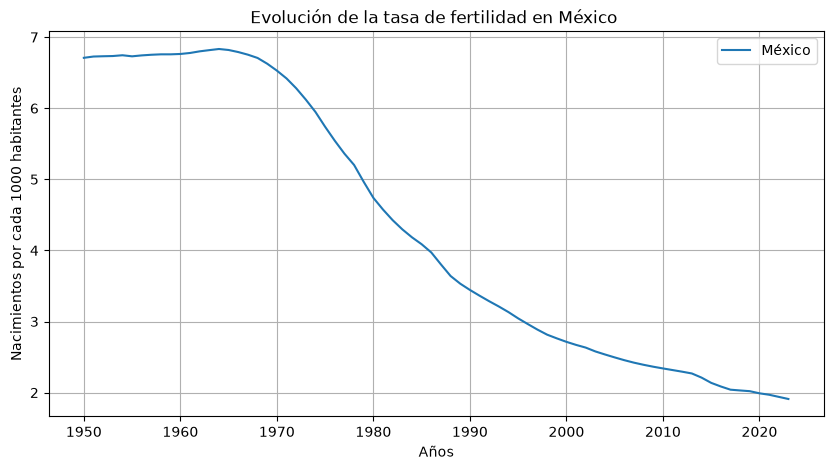

In [102]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico, #eje x
    tasa_mexico, #eje y
    label="México", #titulo
)
plt.title("Evolución de la tasa de fertilidad en México ")
plt.xlabel("Años")
plt.ylabel("Nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()

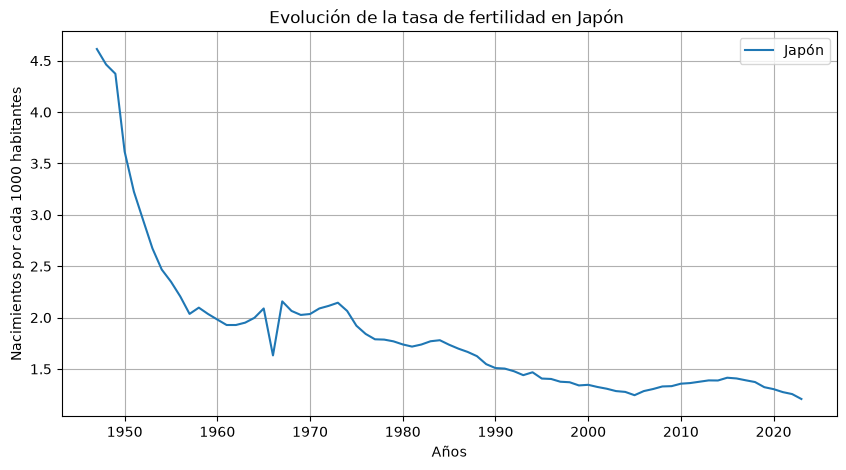

In [103]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_japon, #eje x
    tasa_japon, #eje y
    label="Japón", #titulo
)
plt.title("Evolución de la tasa de fertilidad en Japón ")
plt.xlabel("Años")
plt.ylabel("Nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()

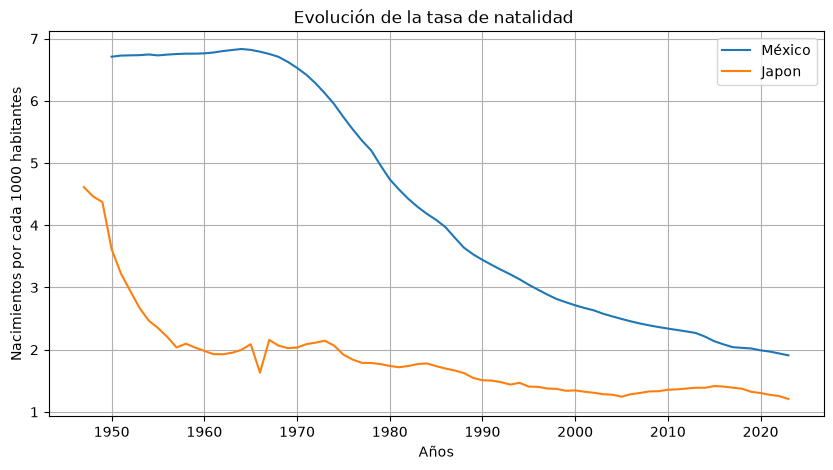

In [104]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico, #eje x
    tasa_mexico, #eje y
    label="México", #titulo
)
plt.plot(
    anios_japon, #eje x
    tasa_japon, #eje y
    label="Japon", #titulo
)

plt.title("Evolución de la tasa de natalidad ")
plt.xlabel("Años")
plt.ylabel("Nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()
plt.show()

In [105]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()

In [106]:
mascara_coincidencia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [107]:
mascara_coincidencia_anios.shape

(77,)

In [108]:
anios_japon = anios_japon[mascara_coincidencia_anios]
anios_japon.shape

(74,)

In [110]:
diferencia_mx_jp = tasa_mexico - anios_japon

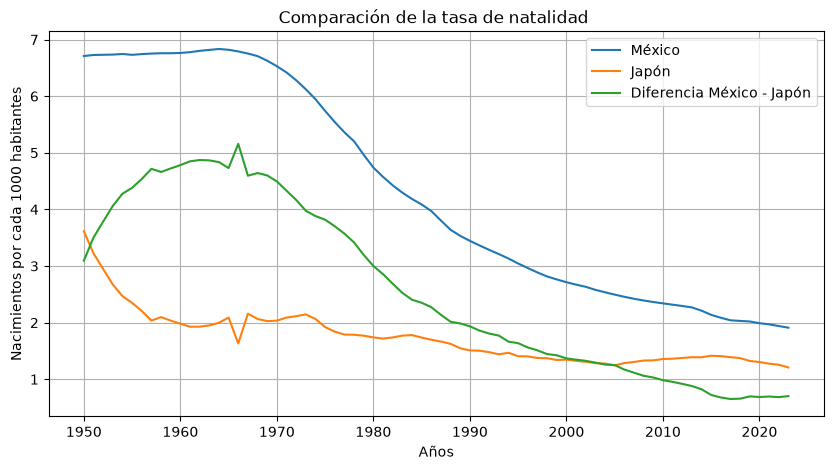

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico, #eje x
    tasa_mexico, #eje y
    label="México", #titulo
)
# Alinear Japón con México usando la misma máscara de años

tasa_japon_ajustados = tasa_japon[mascara_coincidencia_anios]
diferencia_mx_jp = tasa_mexico - tasa_japon_ajustados

plt.plot(
    anios_japon,  # eje x
    tasa_japon_ajustados,   # eje y
    label="Japón",
)
plt.plot(
    anios_mexico, #eje x
    diferencia_mx_jp, #eje y
    label="Diferencia México - Japón", #titulo
)

plt.title("Comparación de la tasa de natalidad ")
plt.xlabel("Años")
plt.ylabel("Nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()

In [117]:
brazil = df[(df['entity'] == 'Brazil')]
anios_brazil = brazil["year"].to_numpy()
tasa_brazil = brazil["fertility_rate_hist"].to_numpy()
diferencia_mx_br = tasa_mexico - tasa_brazil

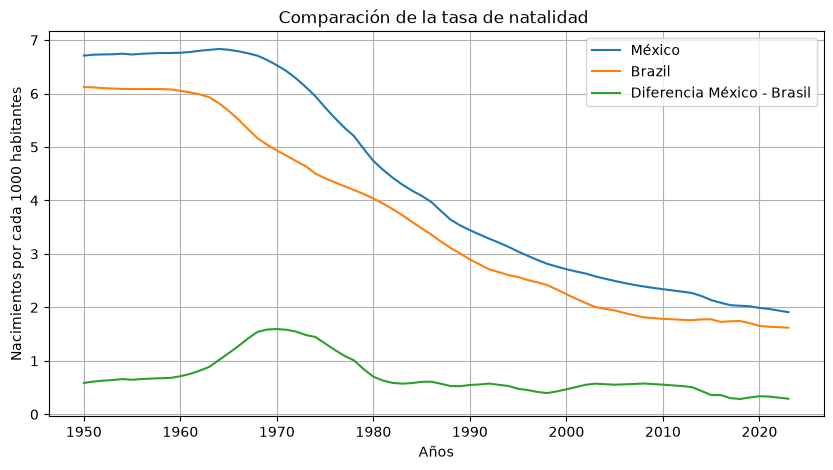

In [118]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico, #eje x
    tasa_mexico, #eje y
    label="México", #titulo
)
plt.plot(
    anios_brazil,  # eje x
    tasa_brazil,   # eje y
    label="Brazil",
)
plt.plot(
    anios_mexico, #eje x
    diferencia_mx_br, #eje y
    label="Diferencia México - Brasil", #titulo
)
plt.title("Comparación de la tasa de natalidad ")
plt.xlabel("Años")
plt.ylabel("Nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()